# Max-Projection: cross-model comparison

7 models on Max-Projection (selected arm): Cellpose, InstanSeg, Stardist, Dist U-Net (trained from scratch), Mesmer,
Cellpose-SAM and MicroSAM (zero-shot). Every model is scored on the same 250 test images
(132 / 10 / 89 / 19 for Vectra / CODEX / MACSima / Zeiss), pooled over datasets.
Scores come from `results/all_runs.csv` (`validation/consolidate.py`).

In [1]:
import sys
from itertools import combinations
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io
from matplotlib.colors import PowerNorm
from scipy.stats import mannwhitneyu

from import_util import data_path
from validation.consolidate import DATASETS, load, scores_dir
from validation.multi_model import pred_path_for
from validation.object_level import split_merge_counts

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Mesmer", "Dist U-Net", "Cellpose-SAM", "MicroSAM"]
BOTTOM_TO_TOP = MODEL_ORDER[::-1]  # horizontal boxplots and the heatmap are drawn bottom to top
COLORS = {  # seaborn colorblind palette
    "Cellpose": "#0173B2", "InstanSeg": "#DE8F05", "Stardist": "#029E73", "Mesmer": "#D55E00",
    "Dist U-Net": "#CC78BC", "Cellpose-SAM": "#CA9161", "MicroSAM": "#949494",
}
LABELS = {"Rec": "Recall", "Prec": "Precision"}
RADAR_METRICS = ["PQ", "mIoU", "mDICE", "F1", "Rec", "Prec"]

## Load

In [2]:
scores = load()  # one row per test image of every run
scores = scores[(scores["Modality"] == "MaxProj") & (scores["Arm"] == "selected") & scores["Model"].isin(MODEL_ORDER)]

# every model must have scored exactly the same images
assert scores.groupby("Model")["ID"].apply(frozenset).nunique() == 1, "models were scored on different images"
print(f"{scores['ID'].nunique()} images x {scores['Model'].nunique()} models")
scores.head()

250 images x 7 models


,Model,Dataset,Modality,Arm,Fold,Run,ID,Prec,Rec,F1,...,Area,Perimeter,Solidity,Eccentricity,Rectangularity,Major Axis,Minor Axis,Compactness,Aspect Ratios,# Cells
0,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.772222,0.487719,0.597849,...,486.855556,90.231556,0.909034,0.735266,0.662218,31.987700,19.563412,0.729888,1.713498,180
1,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.543379,0.352071,0.427289,...,399.178082,93.268745,0.871949,0.796131,0.614666,33.625810,16.122672,0.608399,2.149910,219
2,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.571429,0.417910,0.482759,...,384.995918,87.888310,0.877116,0.774406,0.626406,30.845971,16.582867,0.626017,1.937359,245
3,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.659218,0.556604,0.603581,...,524.938547,96.730130,0.896752,0.745845,0.636757,33.841469,20.139882,0.685191,1.816212,179
4,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.606557,0.388451,0.473600,...,458.012295,92.656685,0.884473,0.746153,0.644012,32.804142,18.282298,0.665981,1.795117,244


## Per-image boxplots (F1, mIoU)

F1 and PQ, and mIoU and mDICE, are near-duplicates per image (r = 0.97-0.98), so F1 and mIoU stand in for all four;
the others are in the supplementary figure below. Gray box = quartiles, whiskers = 1.5 x IQR, diamond = mean,
faint lines follow each image across models.

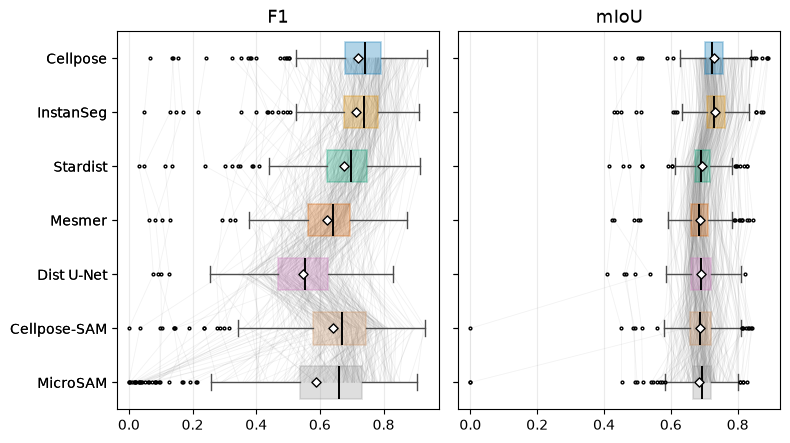

In [3]:
def plot_boxplots(metrics):
    fig, axs = plt.subplots(1, len(metrics), sharey=True,
                            figsize=(3.4 * len(metrics) + 1.2, 0.42 * len(MODEL_ORDER) + 1.6))
    y = np.arange(1, len(MODEL_ORDER) + 1)
    for ax, metric in zip(np.atleast_1d(axs), metrics):
        wide = scores.pivot(index="ID", columns="Model", values=metric)[BOTTOM_TO_TOP]  # image x model

        ax.plot(wide.values.T, y, color="gray", alpha=0.1, linewidth=0.6)  # one faint line per image
        bp = ax.boxplot(
            [wide[m] for m in BOTTOM_TO_TOP], tick_labels=BOTTOM_TO_TOP, orientation="horizontal",
            patch_artist=True, widths=0.6, medianprops=dict(color="black", linewidth=1.4),
            flierprops=dict(marker="o", markersize=2),
            whiskerprops=dict(color="0.3", linewidth=1), capprops=dict(color="0.3", linewidth=1),
        )
        for patch, model in zip(bp["boxes"], BOTTOM_TO_TOP):
            patch.set(facecolor=COLORS[model], alpha=0.3, edgecolor=COLORS[model], linewidth=1.2)
        ax.scatter(wide.mean(), y, marker="D", s=22, color="white", edgecolor="black", linewidth=1, zorder=4)

        pad = 0.04 * (wide.values.max() - wide.values.min())
        ax.set_xlim(wide.values.min() - pad, wide.values.max() + pad)
        ax.set_title(LABELS.get(metric, metric), fontsize=13)
        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)
    fig.tight_layout()
    return fig


fig = plot_boxplots(["F1", "mIoU"])
fig.savefig(EXPORT_DIR / "Boxplots_MaxProj_F1_mIoU.pdf", bbox_inches="tight")

## Pairwise significance

Mann-Whitney U test for every model pair and both metrics, Bonferroni-corrected jointly (2 metrics x 21 pairs = 42 tests).
The test treats the images as independent samples. Heatmap: F1 in the upper-left triangle, mIoU in the lower-right;
colour is -log10(p_bonf), only for significant pairs (p_bonf < 0.05). + / - means the row model scores higher / lower
than the column model.

In [4]:
rows = []
for metric in ["F1", "mIoU"]:
    wide = scores.pivot(index="ID", columns="Model", values=metric)
    for a, b in combinations(BOTTOM_TO_TOP, 2):
        _, p = mannwhitneyu(wide[a], wide[b])
        rows.append({"metric": metric, "model_a": a, "model_b": b, "mean_diff": wide[a].mean() - wide[b].mean(), "p_raw": p})

sig = pd.DataFrame(rows)
sig["p_bonf"] = (sig["p_raw"] * len(sig)).clip(upper=1.0)
sig["significant"] = sig["p_bonf"] < 0.05

for metric in ["F1", "mIoU"]:
    print(f"=== {metric}: significant pairs (Bonferroni p < 0.05) ===")
    display(sig[(sig["metric"] == metric) & sig["significant"]].sort_values("p_bonf"))

=== F1: significant pairs (Bonferroni p < 0.05) ===


,metric,model_a,model_b,mean_diff,p_raw,p_bonf,significant
13,F1,Dist U-Net,InstanSeg,-0.167366,2.944547e-45,1.236710e-43,True
14,F1,Dist U-Net,Cellpose,-0.173760,5.161937e-45,2.168013e-43,True
12,F1,Dist U-Net,Stardist,-0.128948,1.237437e-30,5.197235e-29,True
17,F1,Mesmer,Cellpose,-0.098530,1.116934e-25,4.691124e-24,True
16,F1,Mesmer,InstanSeg,-0.092136,1.470028e-24,6.174117e-23,True
6,F1,Cellpose-SAM,Dist U-Net,0.094935,9.772379e-19,4.104399e-17,True
5,F1,MicroSAM,Cellpose,-0.130411,5.325757e-17,2.236818e-15,True
4,F1,MicroSAM,InstanSeg,-0.124018,4.981471e-15,2.092218e-13,True
11,F1,Dist U-Net,Mesmer,-0.075230,8.354610e-14,3.508936e-12,True
10,F1,Cellpose-SAM,Cellpose,-0.078824,2.389961e-12,1.003783e-10,True


=== mIoU: significant pairs (Bonferroni p < 0.05) ===


,metric,model_a,model_b,mean_diff,p_raw,p_bonf,significant
37,mIoU,Mesmer,InstanSeg,-0.045322,7.809506e-28,3.279993e-26,True
38,mIoU,Mesmer,Cellpose,-0.041959,3.382954e-23,1.420841e-21,True
25,mIoU,MicroSAM,InstanSeg,-0.048544,1.420614e-22,5.966580e-21,True
39,mIoU,Stardist,InstanSeg,-0.037823,3.582563e-22,1.504677e-20,True
30,mIoU,Cellpose-SAM,InstanSeg,-0.043814,1.144941e-21,4.808750e-20,True
34,mIoU,Dist U-Net,InstanSeg,-0.040385,2.715449e-21,1.140489e-19,True
31,mIoU,Cellpose-SAM,Cellpose,-0.040451,1.547919e-17,6.501260e-16,True
40,mIoU,Stardist,Cellpose,-0.034460,2.143400e-17,9.002279e-16,True
26,mIoU,MicroSAM,Cellpose,-0.045181,2.554573e-17,1.072921e-15,True
35,mIoU,Dist U-Net,Cellpose,-0.037022,1.444240e-16,6.065810e-15,True


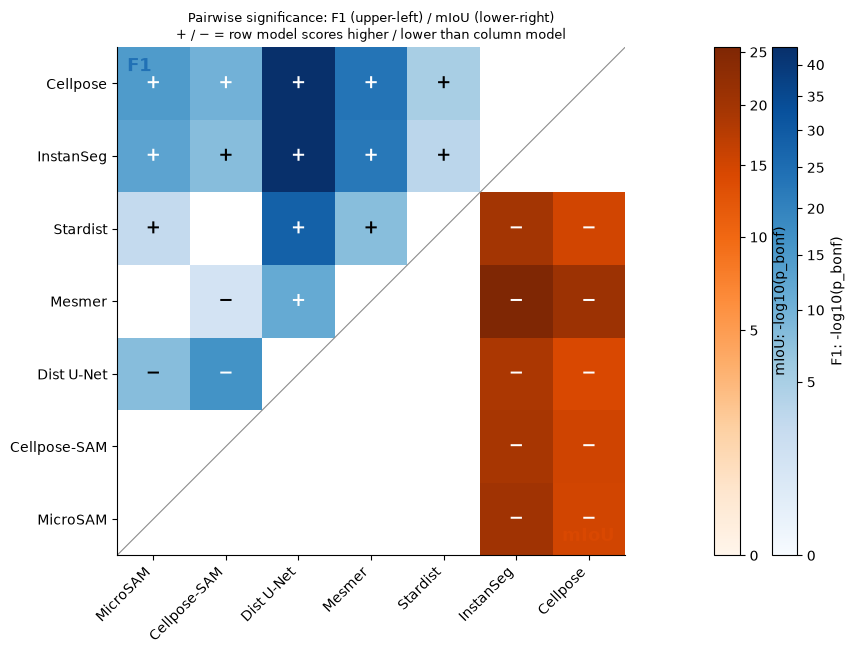

In [5]:
LOWER, UPPER = "F1", "mIoU"  # which metric fills which triangle
n = len(BOTTOM_TO_TOP)
pos = {m: i for i, m in enumerate(BOTTOM_TO_TOP)}

# p_mat[row, col] and sign[row, col] = sign of (row model - col model) mean difference
p_mat = np.full((n, n), np.nan)
sign = np.zeros((n, n))
for r in sig.itertuples():
    a, b = pos[r.model_a], pos[r.model_b]
    hi, lo = max(a, b), min(a, b)
    i, j = (hi, lo) if r.metric == LOWER else (lo, hi)
    p_mat[i, j] = r.p_bonf
    sign[i, j] = np.sign(r.mean_diff if i == a else -r.mean_diff)

significant = p_mat < 0.05
log_p = -np.log10(np.clip(p_mat, 1e-300, 1))
lower_tri = np.tri(n, k=-1, dtype=bool)  # row > col
upper_tri = lower_tri.T

fig, ax = plt.subplots(figsize=(9.0, 6.6))
for tri, metric, cmap, cbar_pad in [(lower_tri, LOWER, "Blues", 0.04), (upper_tri, UPPER, "Oranges", 0.14)]:
    shown = tri & significant
    # each triangle gets its own colour scale; PowerNorm stretches the low end so p ~ 1e-8 is still clearly coloured
    norm = PowerNorm(gamma=0.5, vmin=0, vmax=log_p[shown].max(initial=1))
    im = ax.imshow(np.ma.masked_where(~shown, log_p), cmap=cmap, norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=cbar_pad, label=f"{metric}: -log10(p_bonf)")
    for i, j in zip(*np.nonzero(shown)):
        ax.text(j, i, "+" if sign[i, j] > 0 else "−", ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if norm(log_p[i, j]) > 0.45 else "black")

ax.set_xticks(range(n)); ax.set_xticklabels(BOTTOM_TO_TOP, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(BOTTOM_TO_TOP)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)  # not inverted: the last model is on top, as in the boxplot
ax.plot([-0.5, n - 0.5], [-0.5, n - 0.5], color="0.55", linewidth=0.8)
ax.set_aspect("equal")
ax.text(0.02, 0.98, LOWER, transform=ax.transAxes, ha="left", va="top", fontsize=13, fontweight="bold", color="#2171B5")
ax.text(0.98, 0.02, UPPER, transform=ax.transAxes, ha="right", va="bottom", fontsize=13, fontweight="bold", color="#D94801")
ax.set_title(f"Pairwise significance: {LOWER} (upper-left) / {UPPER} (lower-right)\n"
             "+ / − = row model scores higher / lower than column model", fontsize=9.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.savefig(EXPORT_DIR / "Significance_F1_mIoU_Combined_MaxProj.pdf", bbox_inches="tight")

## Rank stability

Rank of each model's mean PQ within each dataset (1 = best): does the pooled ranking hold on every dataset?

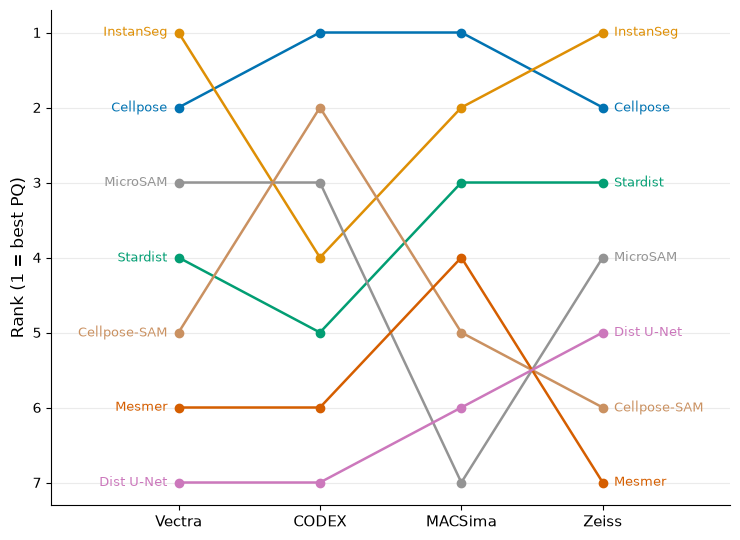

In [6]:
by_dataset = scores.groupby(["Model", "Dataset"])["PQ"].mean().unstack("Dataset")[DATASETS]
ranks = by_dataset.rank(ascending=False, axis=0)  # 1 = best, per dataset

fig, ax = plt.subplots(figsize=(7.5, 5.5))
x = np.arange(len(DATASETS))
for model in ranks.mean(axis=1).sort_values().index:
    y = ranks.loc[model].values
    ax.plot(x, y, color=COLORS[model], linewidth=1.8, marker="o", markersize=6)
    ax.annotate(model, (x[-1] + 0.08, y[-1]), va="center", fontsize=9, color=COLORS[model])
    ax.annotate(model, (x[0] - 0.08, y[0]), va="center", ha="right", fontsize=9, color=COLORS[model])

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_yticks(range(1, len(MODEL_ORDER) + 1))
ax.set_ylabel("Rank (1 = best PQ)", fontsize=12)
ax.invert_yaxis()
ax.set_xlim(-0.9, len(DATASETS) - 1 + 0.9)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "RankStability_MaxProj_PQ.pdf", bbox_inches="tight")

## Precision vs. recall

Mean per model, datasets weighted equally. Gray curves are iso-F1 lines.

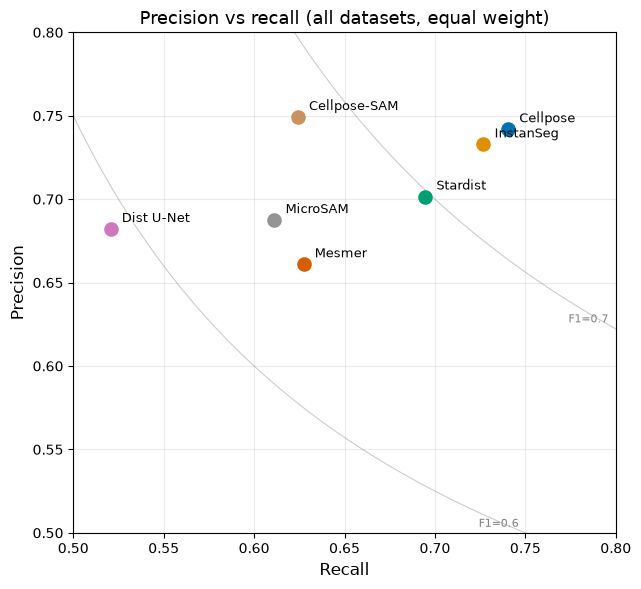

In [7]:
pr = scores.groupby(["Model", "Dataset"])[["Prec", "Rec"]].mean().groupby("Model").mean()

fig, ax = plt.subplots(figsize=(7, 6.5))
lo, hi = 0.5, 0.8
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

rec = np.linspace(0.01, 1.0, 400)
for f1 in (0.5, 0.6, 0.7, 0.8):
    prec = np.where(2 * rec > f1, f1 * rec / (2 * rec - f1), np.nan)
    ax.plot(rec, prec, color="gray", alpha=0.4, linewidth=0.8)
    visible = np.flatnonzero((rec >= lo) & (rec <= hi) & (prec >= lo) & (prec <= hi))
    if len(visible):  # label the last visible point of the curve
        ax.annotate(f"F1={f1}", (rec[visible[-1]], prec[visible[-1]]), textcoords="offset points",
                    xytext=(-4, 4), fontsize=8, color="gray", ha="right")

for model in MODEL_ORDER:
    ax.scatter(pr.loc[model, "Rec"], pr.loc[model, "Prec"], color=COLORS[model], s=90, zorder=3)
    ax.annotate(model, (pr.loc[model, "Rec"], pr.loc[model, "Prec"]), textcoords="offset points",
                xytext=(8, 5), fontsize=9)

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision vs recall (all datasets, equal weight)", fontsize=13)
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
fig.savefig(EXPORT_DIR / "PR_MaxProj.pdf", bbox_inches="tight")

## F1 vs. IoU matching threshold

Mean F1 over all images when a prediction counts as a match at the given IoU. The dashed line is the threshold (0.5) used elsewhere.

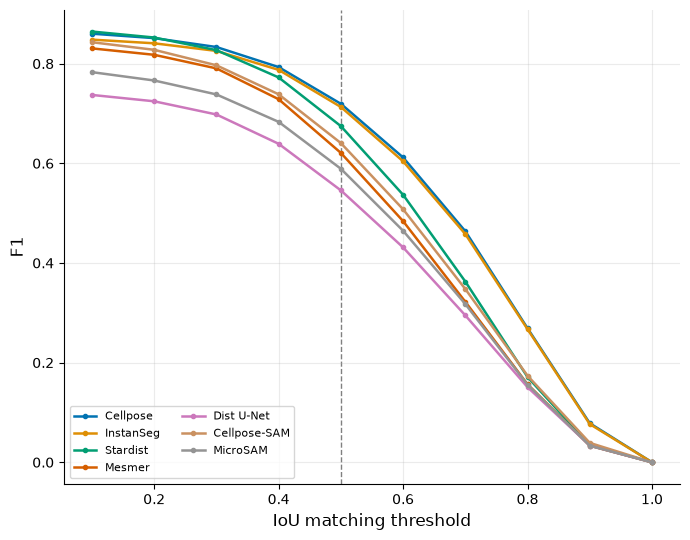

In [8]:
f1_cols = [c for c in scores.columns if c.startswith("F1@")]
thresholds = [float(c.split("@")[1]) for c in f1_cols]
sweep = scores.groupby("Model")[f1_cols].mean()

fig, ax = plt.subplots(figsize=(7, 5.5))
for model in MODEL_ORDER:
    ax.plot(thresholds, sweep.loc[model], color=COLORS[model], linewidth=1.8, marker="o", markersize=3, label=model)
ax.axvline(0.5, color="0.5", linestyle="--", linewidth=1, zorder=0)
ax.set_xlabel("IoU matching threshold", fontsize=12)
ax.set_ylabel("F1", fontsize=12)
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(fontsize=8, loc="lower left", ncol=2)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "F1_Sweep_MaxProj.pdf", bbox_inches="tight")

## Split and merge rates

Split rate: share of GT objects that overlap two or more predictions (IoU > 0.2).
Merge rate: share of predicted objects that overlap two or more GT objects. Together they separate over- from
under-segmentation. This loads every GT and prediction image, so it takes a while.

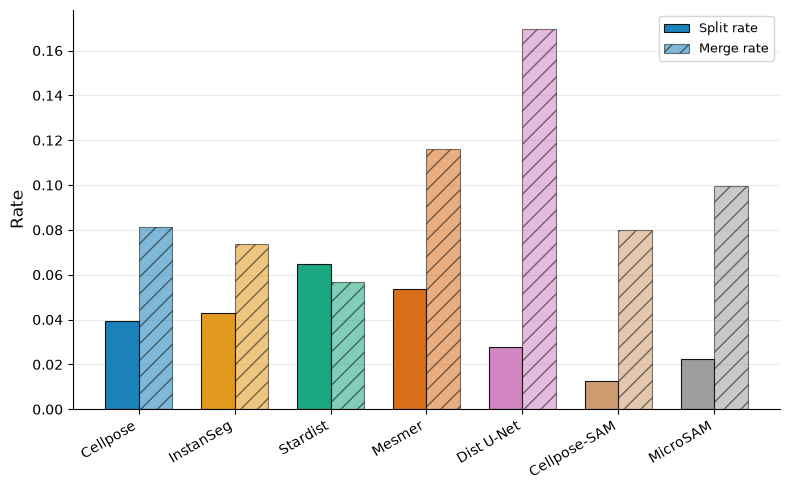

In [9]:
rows = []
for r in scores.itertuples():
    pred = skimage.io.imread(pred_path_for(str(scores_dir(r.Model, r.Dataset)), r.Run, r.Fold, r.ID))
    rows.append({**split_merge_counts(skimage.io.imread(data_path(r.ID)), pred, iou_thr=0.2), "Model": r.Model})
split_merge = pd.DataFrame(rows)

totals = split_merge.groupby("Model")[["n_split_gt", "n_gt", "n_merge_pred", "n_pred"]].sum().loc[MODEL_ORDER]
rates = pd.DataFrame({
    "Split rate": totals["n_split_gt"] / totals["n_gt"],
    "Merge rate": totals["n_merge_pred"] / totals["n_pred"],
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.35
for k, (kind, alpha, hatch) in enumerate([("Split rate", 0.9, ""), ("Merge rate", 0.5, "//")]):
    ax.bar(x + (k - 0.5) * width, rates[kind], width, color=[COLORS[m] for m in MODEL_ORDER],
           alpha=alpha, hatch=hatch, edgecolor="black", linewidth=0.8, label=kind)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha="right")
ax.set_ylabel("Rate", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "SplitMerge_MaxProj.pdf", bbox_inches="tight")

## Supplementary: per-dataset radar plots

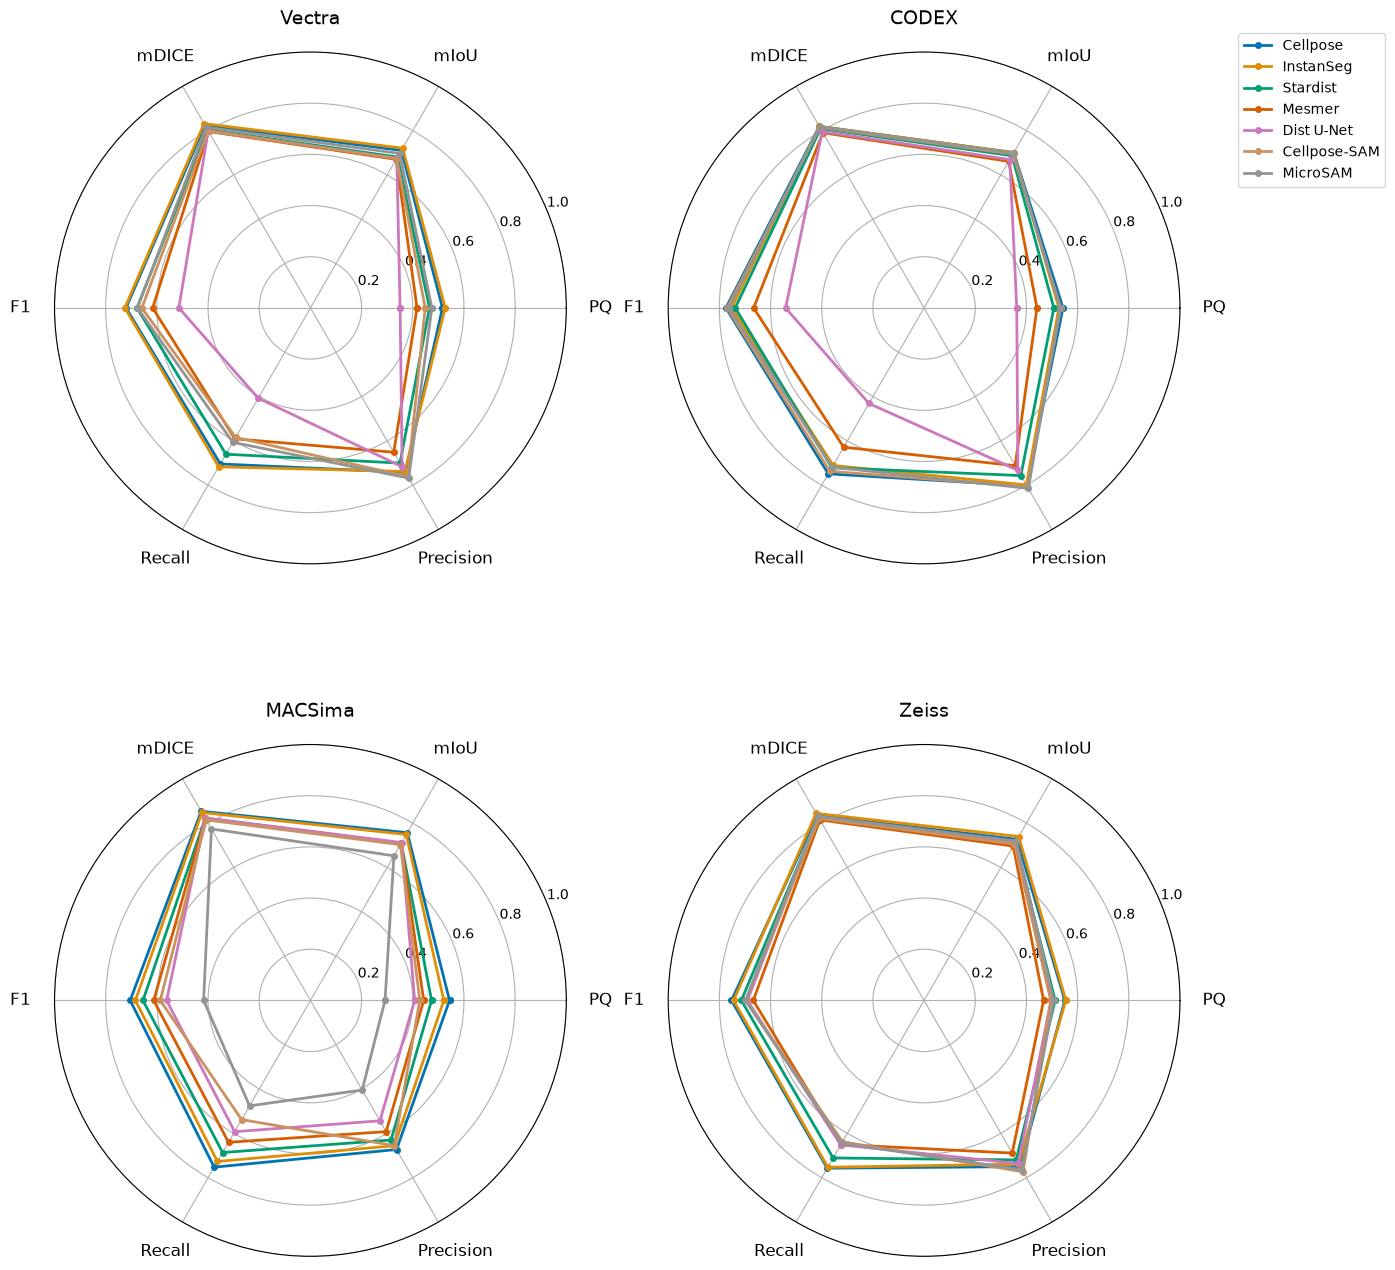

In [10]:
by_ds = scores.groupby(["Model", "Dataset"])[RADAR_METRICS].mean()
angles = np.linspace(0, 2 * np.pi, len(RADAR_METRICS), endpoint=False).tolist()
angles += angles[:1]

fig, axs = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))
for ax, dataset in zip(axs.ravel(), DATASETS):
    for model in MODEL_ORDER:
        values = by_ds.loc[(model, dataset), RADAR_METRICS].tolist()
        ax.plot(angles, values + values[:1], linewidth=2, color=COLORS[model], label=model, marker="o", markersize=4)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([LABELS.get(m, m) for m in RADAR_METRICS], fontsize=12)
    ax.xaxis.set_tick_params(pad=14)
    ax.set_title(dataset, fontsize=14, pad=20)
axs[0, 1].legend(loc="upper left", bbox_to_anchor=(1.1, 1.05), fontsize=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "Radar_MaxProj_ByDataset.pdf", bbox_inches="tight")

## Supplementary: remaining metrics

Same boxplots as above for PQ, mDICE, Recall and Precision.

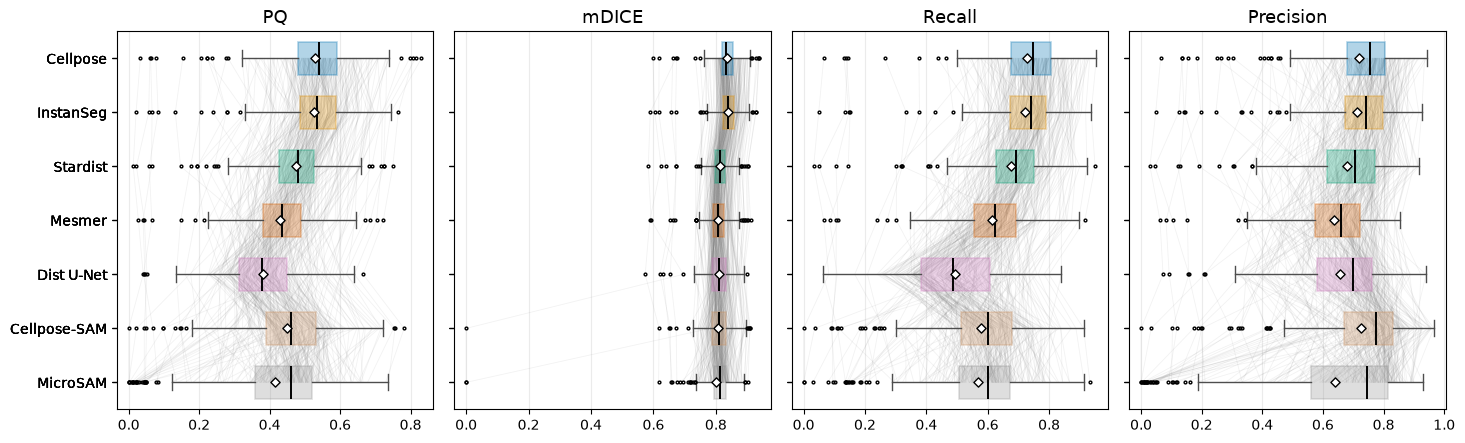

In [11]:
fig = plot_boxplots(["PQ", "mDICE", "Rec", "Prec"])
fig.savefig(EXPORT_DIR / "Boxplots_MaxProj_SupplementaryMetrics.pdf", bbox_inches="tight")